### Understanding the arguments of the darts implementation of TFT

In [ ]:
# def encode_year(idx):
#     return (idx.year - 1950) / 50

# add_encoders={
#     'cyclic': {'future': ['month'], 'past': ['month']},
#     'position': {'past': ['relative'], 'future': ['relative']},
#     'custom': {'past': [encode_year], 'future': [encode_year]},
#     'transformer': Scaler(),
#     'tz': 'Asia/Kolkata'
# }

#The model currently does not know the concept of time. It does not know if a certain date that 
#it is capturing, that date is February of 2023 or is it January of 2025

#So in order to enable that understanding to the model, there is an argument in the implementation of 
#TFT using darts library called as add_encoders. Given below is a detailed explanation of each key within
#this add_encoders dictionary

#1. Here future or past keys mean that the corresponding covariate is being treated as a future 
# or a past covariate. Since each of these variables will be given to the encoder as well as decoder
#therefore, they are being considered as past and future covariates both

#2. the first key i.e., cyclic - this helps to encode the month obtained from the date time index in cyclical
#format. Now because January (1) and December (12) are separated by 11 units numerically but they actually are
#adjacent so cyclical encoding helps retain that adjacency

#Sin(2*np.pi*(t/T)) and Cos(2*np.pi*(t/T)) - where t is the value of the month and T will be 12
#these two coordinates are needed to map onto the unit circle

#3. Second key - i.e., position - this helps model learn where it is relative to the point where it needs to 
# make a forecast. example - 
#Say your forecast origin is October 2025 — the last known data point. You have 60 months of 
# history going back to October 2020.
#The model knows that 
# Why does that distance matter?
# Because the attention mechanism needs to answer: "which past months should I look at most carefully when forecasting?"
# To answer that, it needs to know distances. For example it might learn:
# The month immediately before the forecast origin (position -1) is always relevant
# The month exactly 12 positions back (position -12) is especially relevant because that is last year's festive season
# April 2021 is April, and that it belongs to 2021. But it does not know that April 2021 is 
# 54 months behind the forecast origin. It has no sense of distance from the prediction point.


#4. Encode year - This helps to encode the year so that we the model knows it is 2022
#Notice that we are normalizing the year feature because without normalization - 
#Raw year values like 2022, 2023, 2024 are large numbers. If you fed these directly into the network:
# The year feature would have values in the thousands
# Other features like cyclic month encoding have values between -1 and +1
# The year feature would numerically dominate simply due to its scale — not because it carries more information









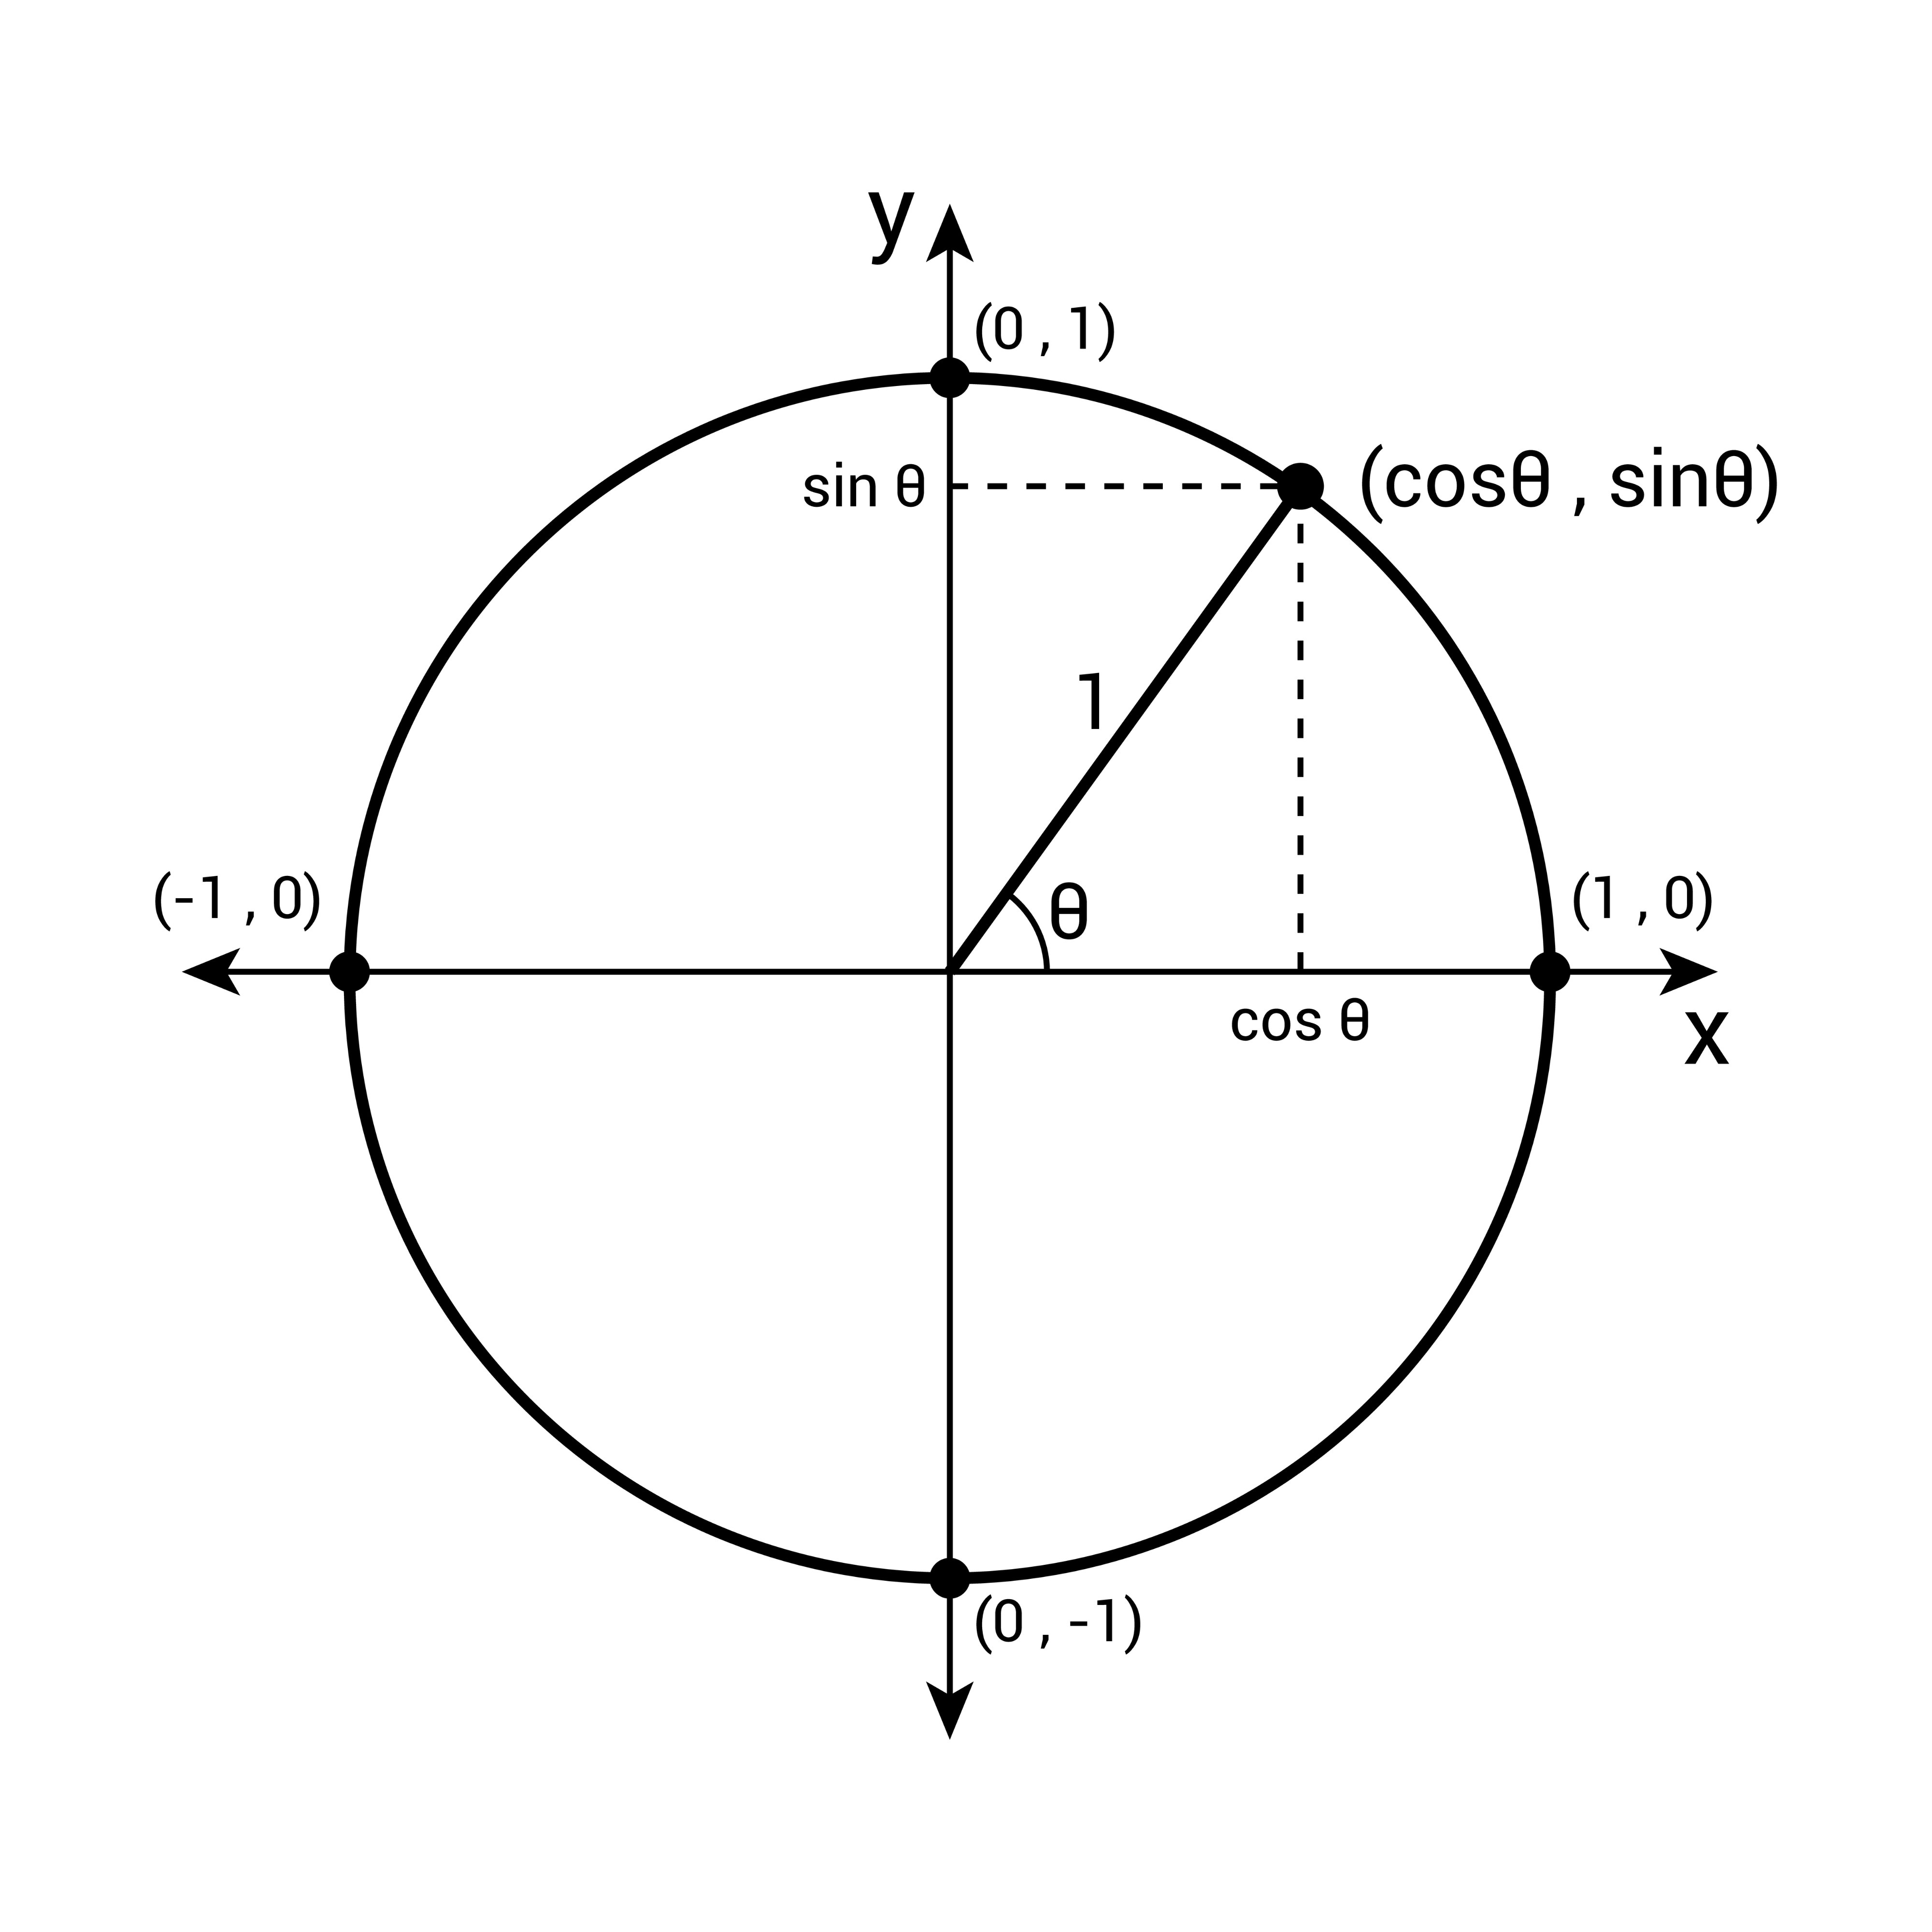